<a href="https://www.kaggle.com/code/samithsachidanandan/working-with-audio-in-python?scriptVersionId=309226794" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Imports 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from glob import glob 

import librosa 
import librosa.display 
import IPython.display as ipd 

from itertools import cycle 

sns.set_theme(style="white", palette=None)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_cycle = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])



# Reading in Audio Files 

There are many types of audio files : mps, wav, m4a, flac, ogg

In [2]:
audio_files = glob('/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/*/*.wav')


In [3]:
ipd.Audio(audio_files[0])

In [4]:
y, sr = librosa.load(audio_files[0])

print(f'y: {y[:10]}')
print(f'Shape y : {y.shape}')
print(f'sr : {sr}')

y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Shape y : (77988,)
sr : 22050


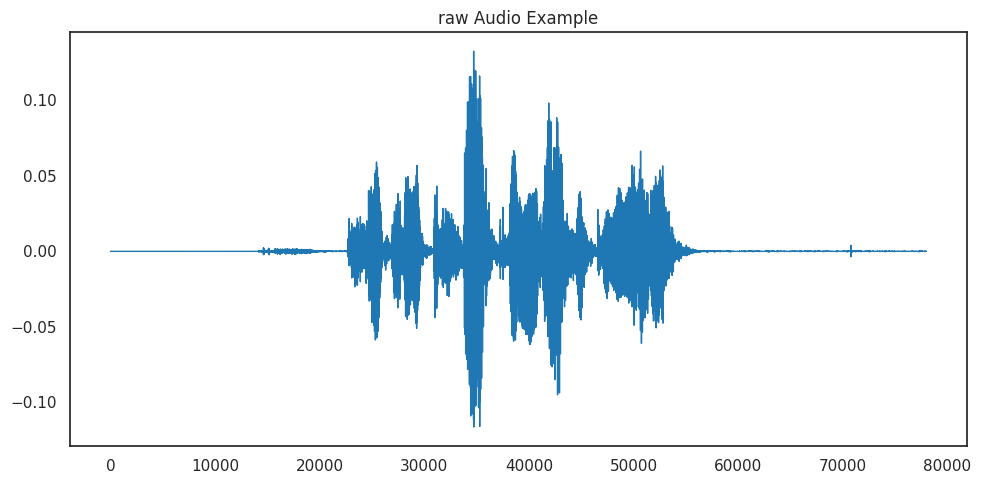

In [5]:
pd.Series(y).plot(figsize=(10,5), lw=1, title="raw Audio Example", color = color_pal[0] )
plt.tight_layout()
plt.show()

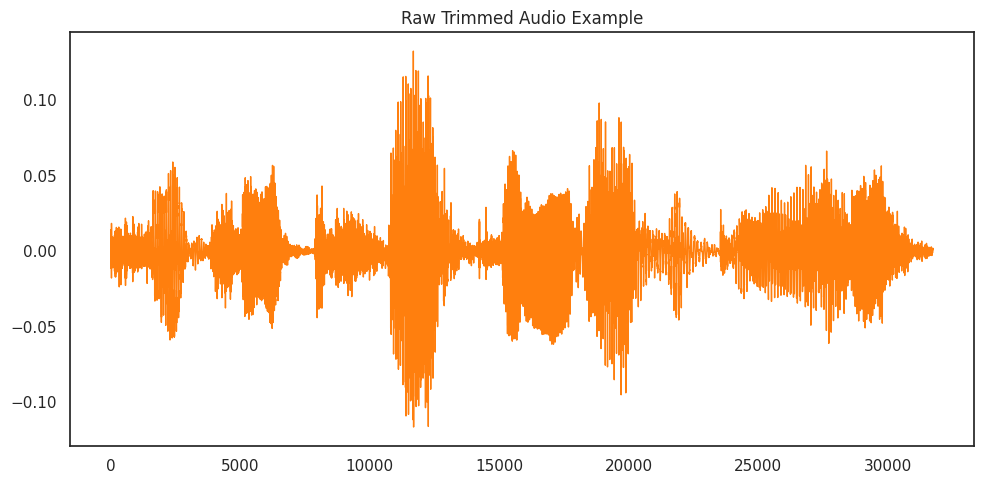

In [6]:
y_trimmed, _  = librosa.effects.trim(y, top_db=20)

pd.Series(y_trimmed).plot(figsize=(10,5), lw=1, title="Raw Trimmed Audio Example", 
                  color = color_pal[1] )
plt.tight_layout()
plt.show()

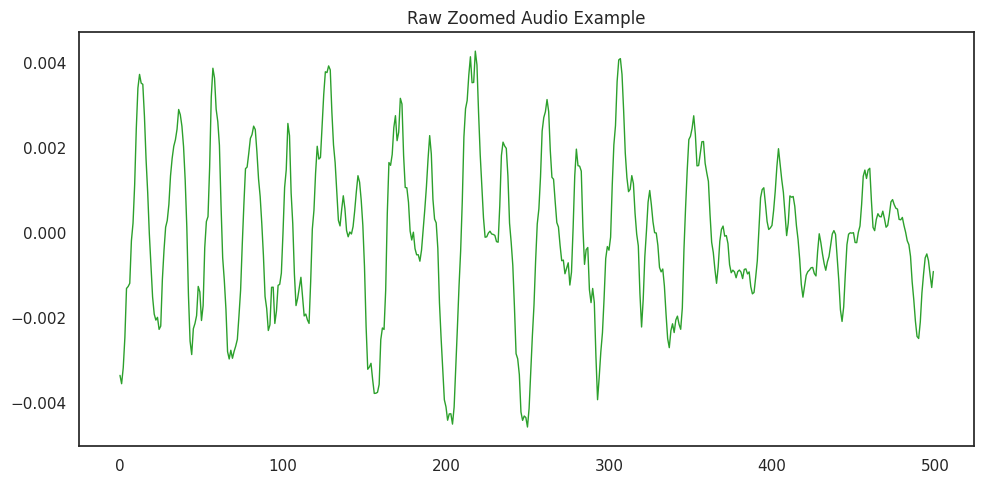

In [7]:
pd.Series(y[30000:30500]).plot(figsize=(10,5), lw=1, title="Raw Zoomed Audio Example", 
                  color = color_pal[2] )
plt.tight_layout()
plt.show()

# Spectogram 

In [8]:
D = librosa.stft(y)
s_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
s_db.shape

(1025, 153)

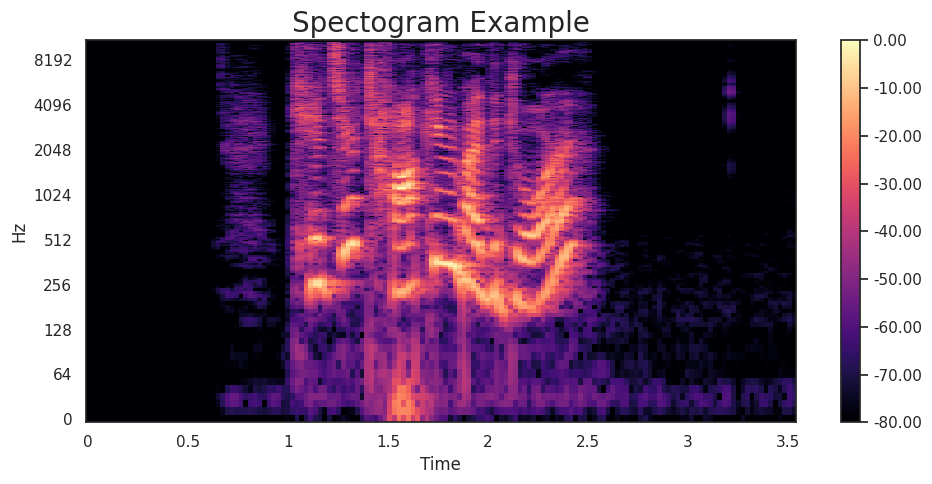

In [9]:
# Plt the transformed audio data 

fig, ax = plt.subplots(figsize=(10,5))
img = librosa.display.specshow(s_db,
                              x_axis= 'time',
                              y_axis= 'log',
                              ax=ax)
ax.set_title('Spectogram Example', fontsize=20)
fig.colorbar(img, ax=ax, format=f"%0.2f")
plt.tight_layout()
plt.show()

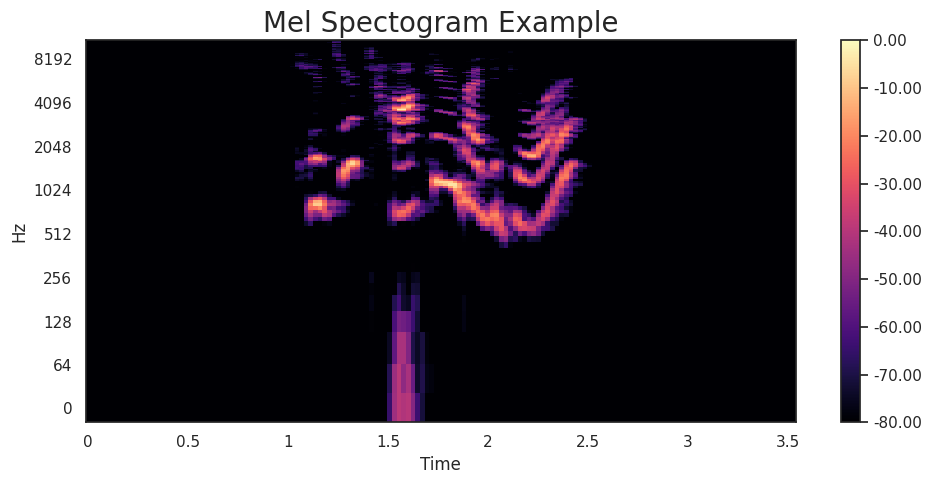

In [10]:
S = librosa.feature.melspectrogram(y=y, 
                               sr=sr, 
                               n_mels=128 * 2,)

S_db_mel = librosa.amplitude_to_db(S, ref=np.max)

fig, ax = plt.subplots(figsize=(10,5))
img = librosa.display.specshow(S_db_mel,
                              x_axis= 'time',
                              y_axis= 'log',
                              ax=ax)
ax.set_title('Mel Spectogram Example', fontsize=20)
fig.colorbar(img, ax=ax, format=f"%0.2f")
plt.tight_layout()
plt.show()